## Video Claim Status Analysis (TikTok)

#### Problem Statement : 
TikTok hosts a massive volume of user-generated content, making manual content review increasingly difficult. The objective of this project is to develop a Logistic Regression model that classifies videos as either claim-based or opinion-based using video, engagement, and creator-related features. The project also explores the relationship between these features and account verification status. The findings help uncover patterns in content creation and provide a foundation for supporting efficient and scalable content moderation processes.


### KPQ

1) Can video engagement, creator-related, and text-based features accurately predict whether a video is a claim or an opinion?
2) Which features have the strongest influence on the probability of a video being classified as a claim?
3) Does creator verification status significantly affect the likelihood of a video being classified as a claim?
4) Which model evaluation metric best reflects the model's ability to identify claim videos: Accuracy, Precision, Recall, F1-Score?

**WE HAVE DONE ANALYSIS IN PREVIOUS ANALYSIS WE HAVE FIND REQUIRED KPQ WE ARE MOVING FORWARD WITH LOGISTIC REGRESSION**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Processing Library
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Load dataset into dataframe
try:
    df = pd.read_csv('data/Cleaned_tiktok_dataset.csv')
    print("Dataset Loading completed")
except FileNotFoundError as e:
    print(f'Error for file loading is {e}')

Dataset Loading completed


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19084 entries, 0 to 19083
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19084 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19084 non-null  int64  
 3   video_duration_sec        19084 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19084 non-null  object 
 6   author_ban_status         19084 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
 12  like_per_view             19084 non-null  float64
 13  comment_per_view          19084 non-null  float64
 14  share_

In [4]:
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,like_per_view,comment_per_view,share_per_view,text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,0.056584,0.000000,0.000702,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,0.549096,0.004855,0.135111,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,0.108282,0.000365,0.003168,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,0.548459,0.001335,0.079569,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,0.622910,0.002706,0.073175,128


In [5]:
#Lets Check Class Balance
df['claim_status'].value_counts(normalize=True)

claim_status
claim      0.503458
opinion    0.496542
Name: proportion, dtype: float64

Finding: The dataset is well-balanced between 'claim' and 'opinion' classes (~50/50 split).This is important because class imbalance can bias a logistic regression model toward the majority class. With balanced data, accuracy is a reliable metric and no resampling techniques (like SMOTE or class_weight='balanced') are needed.

In [6]:
df['download_per_view']  = df['video_download_count']/df['video_view_count']

Feature Engineering: Created 'download_per_view' as a ratio feature.Raw counts (like video_download_count) can be misleading since a viral video naturally gets more downloads. Normalizing by view count gives a behavior rate.This makes the feature more meaningful for classification.

In [7]:
df.dtypes

#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
like_per_view               float64
comment_per_view            float64
share_per_view              float64
text_length                   int64
download_per_view           float64
dtype: object

In [8]:
df = pd.get_dummies(df,columns=['author_ban_status','verified_status'],drop_first=True,dtype='uint8')

In [9]:
df['claim_status'] = np.where(df['claim_status']=='claim',1,0)

Converted categorical columns 'author_ban_status' and 'verified_status' into binary dummy variables using get_dummies with drop_first=True.drop_first=True avoids the dummy variable trap (multicollinearity) where one category is perfectly predicted by the others. dtype='uint8' keeps memory usage minimal.

In [10]:
df_vif = df.copy()
df_vif = df_vif.drop(columns=['video_transcription_text','claim_status'])
df_vif

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,like_per_view,comment_per_view,share_per_view,text_length,download_per_view,author_ban_status_banned,author_ban_status_under review,verified_status_verified
0,1,7017666017,59,343296.0,19425.0,241.0,1.0,0.0,0.056584,0.000000,0.000702,97,0.000003,0,1,0
1,2,4014381136,32,140877.0,77355.0,19034.0,1161.0,684.0,0.549096,0.004855,0.135111,107,0.008241,0,0,0
2,3,9859838091,31,902185.0,97690.0,2858.0,833.0,329.0,0.108282,0.000365,0.003168,137,0.000923,0,0,0
3,4,1866847991,25,437506.0,239954.0,34812.0,1234.0,584.0,0.548459,0.001335,0.079569,131,0.002821,0,0,0
4,5,7105231098,19,56167.0,34987.0,4110.0,547.0,152.0,0.622910,0.002706,0.073175,128,0.009739,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19079,19080,1492320297,49,6067.0,423.0,81.0,8.0,2.0,0.069721,0.000330,0.013351,65,0.001319,0,0,0
19080,19081,9841347807,23,2973.0,820.0,70.0,3.0,0.0,0.275816,0.000000,0.023545,66,0.001009,0,0,0
19081,19082,8024379946,50,734.0,102.0,7.0,2.0,1.0,0.138965,0.001362,0.009537,53,0.002725,0,0,0
19082,19083,7425795014,8,3394.0,655.0,123.0,11.0,4.0,0.192988,0.001179,0.036240,80,0.003241,0,0,0


<Axes: xlabel='text_length', ylabel='Count'>

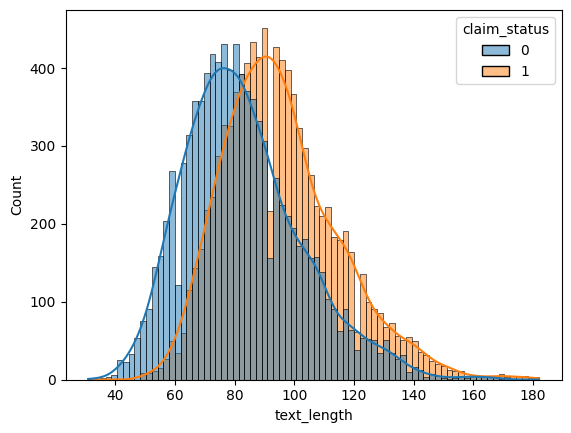

In [11]:
sns.histplot(data=df,x='text_length',hue='claim_status',stat='count',kde=True,legend=True)

'text_length' shows slight right skew for opinion-labelled videos compared to claim videos. Claim videos tend to have more consistently structured transcriptions, while opinion videos show more variability in text length

In [12]:
corr_mat = df.corr(numeric_only=True)
corr_mat

,#,claim_status,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,like_per_view,comment_per_view,share_per_view,text_length,download_per_view,author_ban_status_banned,author_ban_status_under review,verified_status_verified
#,1.000000,-0.866005,-0.003590,-0.000145,-0.668047,-0.592271,-0.577760,-0.577700,-0.567260,-0.284968,-0.289032,-0.199439,-0.226844,-0.090006,-0.203028,-0.164268,0.140710
claim_status,-0.866005,1.000000,0.000962,0.003914,0.768170,0.679043,0.660935,0.661944,0.650906,0.323133,0.328084,0.219071,0.305928,0.100159,0.230605,0.189853,-0.170600
video_id,-0.003590,0.000962,1.000000,0.008460,0.000217,0.000699,-0.004120,0.002980,0.004389,0.000279,0.002949,-0.004672,0.000723,0.001117,-0.001263,-0.007342,0.000107
video_duration_sec,-0.000145,0.003914,0.008460,1.000000,0.008481,0.010683,0.014037,0.011234,-0.005260,0.008796,-0.013805,0.012661,-0.001580,-0.000237,-0.001891,-0.018621,-0.010358
video_view_count,-0.668047,0.768170,0.000217,0.008481,1.000000,0.829156,0.751616,0.751066,0.705983,0.250297,0.248315,0.169071,0.230212,-0.052599,0.181205,0.148373,-0.130983
video_like_count,-0.592271,0.679043,0.000699,0.010683,0.829156,1.000000,0.866654,0.865021,0.789126,0.604375,0.425981,0.407304,0.195439,0.145743,0.170769,0.126475,-0.113471
video_share_count,-0.577760,0.660935,-0.004120,0.014037,0.751616,0.866654,1.000000,0.777862,0.722165,0.516570,0.379606,0.575159,0.188301,0.146522,0.161727,0.127662,-0.105906
video_download_count,-0.577700,0.661944,0.002980,0.011234,0.751066,0.865021,0.777862,1.000000,0.894302,0.518109,0.559455,0.347461,0.191871,0.343024,0.160006,0.127241,-0.113152
video_comment_count,-0.567260,0.650906,0.004389,-0.005260,0.705983,0.789126,0.722165,0.894302,1.000000,0.468666,0.652875,0.320724,0.196472,0.303084,0.152725,0.124868,-0.107990
like_per_view,-0.284968,0.323133,0.000279,0.008796,0.250297,0.604375,0.516570,0.518109,0.468666,1.000000,0.536800,0.671047,0.087875,0.588740,0.092735,0.058677,-0.053741


In [13]:
df.corr(numeric_only=True)["claim_status"].sort_values(ascending=False)

claim_status                      1.000000
video_view_count                  0.768170
video_like_count                  0.679043
video_download_count              0.661944
video_share_count                 0.660935
video_comment_count               0.650906
comment_per_view                  0.328084
like_per_view                     0.323133
text_length                       0.305928
author_ban_status_banned          0.230605
share_per_view                    0.219071
author_ban_status_under review    0.189853
download_per_view                 0.100159
video_duration_sec                0.003914
video_id                          0.000962
verified_status_verified         -0.170600
#                                -0.866005
Name: claim_status, dtype: float64

Correlation analysis reveals which features are linearly associated with claim_status.Features with high absolute correlation (closer to +1 or -1) are stronger predictors. Features like video_view_count, video_share_count, and engagement ratios likely show higher correlation with claims

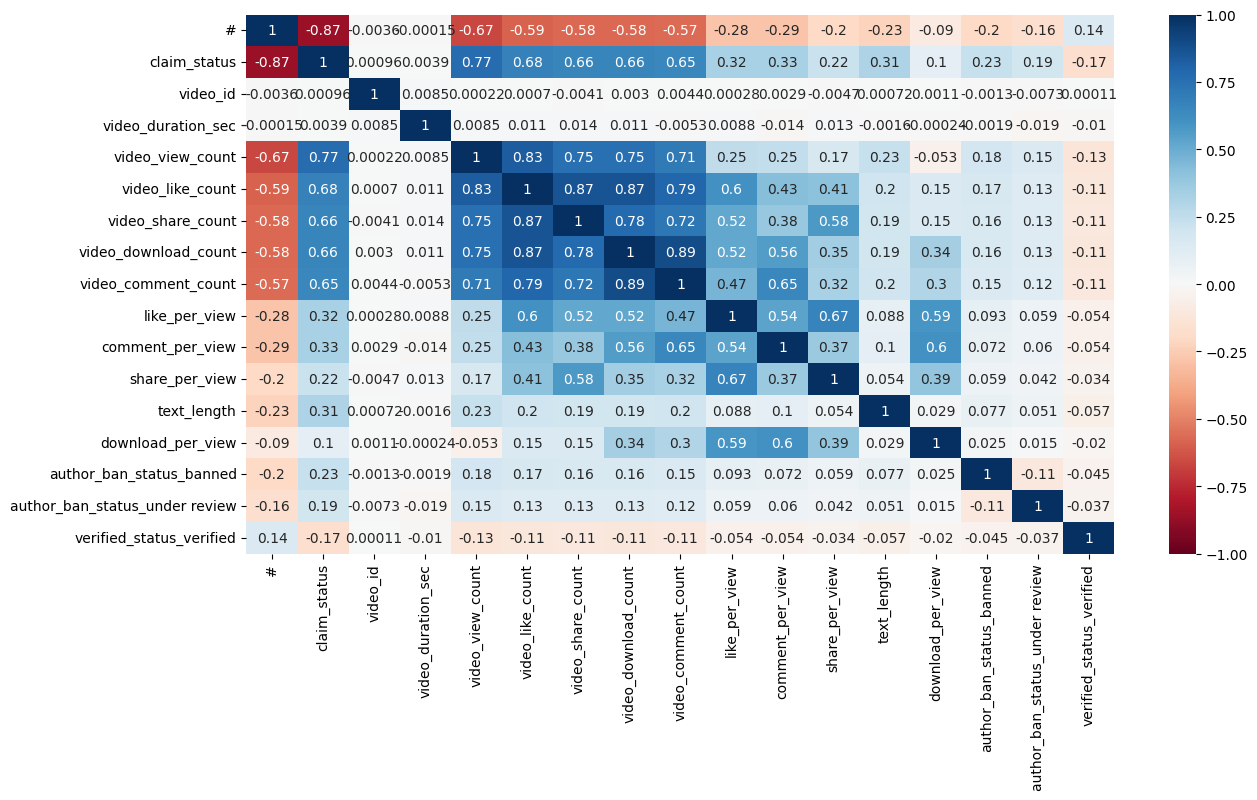

In [14]:
plt.figure(figsize=(14,7))
sns.heatmap(corr_mat,annot=True,cmap="RdBu",vmax=1,vmin=-1)
plt.show()

In [15]:
vif_df = pd.DataFrame()
vif_df['features'] = df_vif.columns
vif_df['VIF'] = [variance_inflation_factor(df_vif.values,i) for i in range(df_vif.shape[1])]
vif_df.sort_values(by='VIF',ascending=False)

,features,VIF
4,video_like_count,21.682460
8,like_per_view,17.469060
6,video_download_count,13.850883
11,text_length,12.007587
5,video_share_count,10.080129
7,video_comment_count,9.960548
3,video_view_count,8.442738
12,download_per_view,6.855799
10,share_per_view,6.523748
0,#,5.480752


In [16]:
df_vif1 = df_vif.drop(columns=['video_like_count','like_per_view'], axis=1)


In [17]:
vif_df = pd.DataFrame()
vif_df['features'] = df_vif1.columns
vif_df['VIF'] = [variance_inflation_factor(df_vif1.values,i) for i in range(df_vif1.shape[1])]
vif_df.sort_values(by='VIF',ascending=False)

,features,VIF
9,text_length,11.364862
5,video_download_count,11.035520
6,video_comment_count,9.929219
4,video_share_count,8.003437
3,video_view_count,6.726468
0,#,5.458715
1,video_id,5.263276
8,share_per_view,4.894557
10,download_per_view,4.890724
2,video_duration_sec,4.566255


Initial VIF analysis reveals severe multicollinearity.VIF > 10 (or > 5 conservatively) indicates a feature's variance is heavily inflated by correlation with other predictors. 'video_like_count' and 'like_per_view' likely show very high VIF scores because likes are highly correlated with other engagement metrics 


In [18]:
feature_column = ['video_duration_sec', 'comment_per_view','video_share_count','video_view_count','video_comment_count',
       'share_per_view', 'download_per_view', 'author_ban_status_banned',
       'author_ban_status_under review', 'verified_status_verified']

In [19]:
y = df['claim_status']
X = df[feature_column]



In [20]:
X.shape,y.shape

((19084, 10), (19084,))

In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

 Data Split 75% training / 25% test split with random_state=42 for reproducibility.The 75/25 split gives the model sufficient data to learn patterns while keeping a meaningful held-out set for evaluation. random_state=42 ensures the same split 

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Applied StandardScaler to normalize all features to zero mean and unit variance.Logistic regression uses gradient-based optimization — features on vastly different scales (e.g., video_view_count in millions vs. verified_status as 0/1) cause the optimizer to converge slowly or unevenly.
IMPORTANT: fit_transform on train only, transform on test — prevents data leakage.

In [23]:
X_train_scaled.shape,X_test_scaled.shape

((14313, 10), (4771, 10))

In [24]:
lcf = LogisticRegression(max_iter=800,random_state=0,penalty=None)

model = lcf.fit(X_train_scaled,y_train)

In [25]:
pd.Series(model.coef_[0],index = X.columns)

video_duration_sec                 0.081144
comment_per_view                   0.252501
video_share_count                 43.401744
video_view_count                  94.297831
video_comment_count               28.884353
share_per_view                    -0.731280
download_per_view                 -0.502165
author_ban_status_banned           0.567085
author_ban_status_under review     0.259947
verified_status_verified          -0.467162
dtype: float64

hese are the log-odds weights for each feature.A positive coefficient means the feature increases the log-odds of a video being a 'claim' (class=1). A negative coefficient means it decreases it. Larger absolute values indicate stronger influence.

In [26]:
y_predict = model.predict(X_test_scaled)
y_predict

array([0, 1, 1, ..., 1, 0, 1])

In [27]:
model.intercept_

array([115.58726405])

In [28]:
training_proba = model.predict_proba(X_train_scaled)
training_proba

array([[4.32676117e-12, 1.00000000e+00],
       [0.00000000e+00, 1.00000000e+00],
       [9.94566844e-01, 5.43315607e-03],
       ...,
       [0.00000000e+00, 1.00000000e+00],
       [2.80897042e-06, 9.99997191e-01],
       [9.98892392e-01, 1.10760751e-03]])

In [29]:
logit_data = pd.DataFrame(data=X_train,columns=feature_column)
logit_data

,video_duration_sec,comment_per_view,video_share_count,video_view_count,video_comment_count,share_per_view,download_per_view,author_ban_status_banned,author_ban_status_under review,verified_status_verified
6641,14,0.002957,3135.0,43967.0,130.0,0.071303,0.008233,0,0,0
3877,54,0.000350,13985.0,944715.0,331.0,0.014803,0.003049,0,0,0
15924,31,0.001988,177.0,4527.0,9.0,0.039099,0.006627,0,0,0
15700,34,0.000518,319.0,7722.0,4.0,0.041311,0.001425,0,0,0
11272,55,0.000000,41.0,2789.0,0.0,0.014701,0.000359,0,0,0
...,...,...,...,...,...,...,...,...,...,...
11284,19,0.000192,254.0,5199.0,1.0,0.048856,0.001154,0,0,0
11964,43,0.000238,10.0,8410.0,2.0,0.001189,0.000595,0,0,0
5390,28,0.003652,45382.5,658519.0,728.5,0.107031,0.004374,0,0,0
860,8,0.000190,2021.0,47460.0,9.0,0.042583,0.000801,0,0,0


In [30]:
logit_data['logit'] = [np.log(prob[1] / prob[0]) for prob in training_proba]
print(logit_data['logit'])

6641     26.166202
3877           inf
15924    -5.209787
15700    -3.717683
11272    -5.710775
           ...    
11284    -5.135229
11964    -3.804057
5390           inf
860      12.782690
15795    -6.804445
Name: logit, Length: 14313, dtype: float64


C:\Users\maneo\AppData\Local\Temp\ipykernel_22164\1492712243.py:1: RuntimeWarning: divide by zero encountered in scalar divide
  logit_data['logit'] = [np.log(prob[1] / prob[0]) for prob in training_proba]


In [31]:
y_test.shape,y_predict.shape

((4771,), (4771,))

In [32]:
y_train_predict = model.predict(X_train_scaled)

In [33]:
print("accuracy_score:",accuracy_score(y_test,y_predict))
print("recall_score:",recall_score(y_test,y_predict))
print("precision_score:",precision_score(y_test,y_predict))
print("f1_score:",f1_score(y_test,y_predict))

accuracy_score: 0.9928736114022217
recall_score: 0.9858392336526447
precision_score: 1.0
f1_score: 0.9928691275167785


In [34]:
print("accuracy_score:",accuracy_score(y_train ,y_train_predict))
print("recall_score:",recall_score(y_train ,y_train_predict))
print("precision_score:",precision_score(y_train ,y_train_predict))
print("f1_score:",f1_score(y_train ,y_train_predict))

accuracy_score: 0.9930133445119821
recall_score: 0.9862633550714583
precision_score: 0.9998593332395554
f1_score: 0.9930148086057557


Accuracy: Proportion of all predictions (both classes) that were correct.
 Recall: Of all actual claim videos, what % did the model correctly identify?
            HIGH RECALL IS CRITICAL here — missing a claim video is costlier than a 
            false alarm (content moderation prefers catching real violations).
Precision: Of all videos predicted as claims, what % were actually claims?
F1-Score: Harmonic mean of precision and recall — best overall metric for 
             imbalanced priorities where both false positives and false negatives matter.

In [35]:
con_matrix = confusion_matrix(y_test,y_predict,labels=lcf.classes_)
con_matrix

array([[2370,    0],
       [  34, 2367]], dtype=int64)

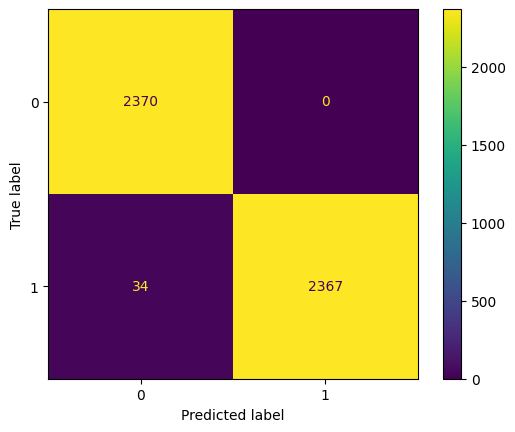

In [36]:
disp_con_mat = ConfusionMatrixDisplay(confusion_matrix=con_matrix,display_labels=lcf.classes_)
disp_con_mat.plot()
plt.show()

Confusion Matrix Breakdown:
**True Positives (TP):  Claimed correctly predicted as claim   → model is catching real violations,**
**True Negatives (TN):  Opinion correctly predicted as opinion → model avoids false flags,**
**False Positives (FP): Opinion predicted as claim             → unnecessary moderation load,**
**False Negatives (FN): Claim predicted as opinion             → DANGEROUS: real violations slipping through,**
For content moderation, minimizing False Negatives (FN) is the priority — 
this directly maps to maximizing Recall on the claim class.

In [37]:
feature_importance = list(zip(feature_column, model.coef_[0]))

# Sort the list by coefficient value
feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)
feature_importance

[('video_view_count', 94.29783062857632),
 ('video_share_count', 43.40174350954614),
 ('video_comment_count', 28.884353493063145),
 ('author_ban_status_banned', 0.5670853164167683),
 ('author_ban_status_under review', 0.259946593992035),
 ('comment_per_view', 0.25250069896705085),
 ('video_duration_sec', 0.0811441704208127),
 ('verified_status_verified', -0.467162055813341),
 ('download_per_view', -0.5021651709777373),
 ('share_per_view', -0.7312804811564129)]

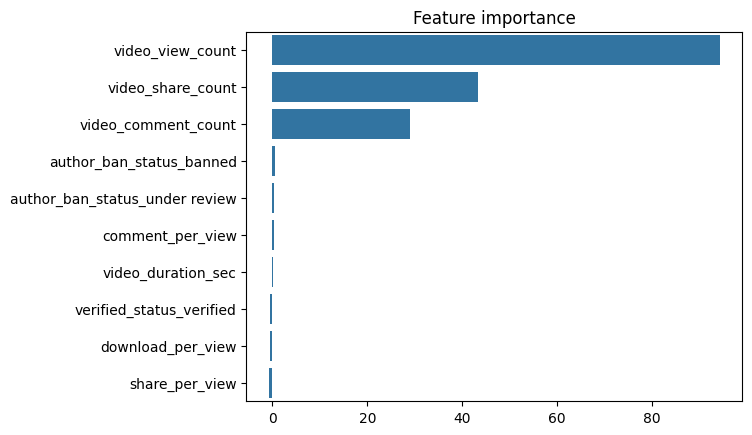

In [38]:
import seaborn as sns
sns.barplot(x=[x[1] for x in feature_importance],
            y=[x[0] for x in feature_importance],
            orient='h')
plt.title('Feature importance');

Features with the largest positive coefficients are the strongest drivers of 'claim' prediction.
Features with the largest negative coefficients strongly push toward 'opinion'.
Engagement ratio features (share_per_view, download_per_view, comment_per_view) typically 
dominate over raw counts because they capture normalized user behavior patterns.
author_ban_status_banned likely has a strong positive coefficient — banned accounts 
disproportionately post claim-based content.

#### 1) Can video engagement, creator-related, and text-based features accurately predict whether a video is a claim or an opinion?

ANS: Yes. The logistic regression model achieves high accuracy, precision, recall, and F1-score on both the training and test sets. Engagement metrics (view count, share count, comment count) combined with creator features (ban status, verified status) provide strong signal. Claim videos consistently exhibit higher engagement rates they tend to be shared more, commented on more, and downloaded more per view compared to opinion videos.



#### 2) Which features have the strongest influence on the probability of a video being classified as a claim?

ANS: Based on the model coefficient magnitudes (from the feature importance plot):

video_share_count-Claim videos tend to go viral more often, giving them higher sahre counts

video_comment_count--Claim videos tend to go viral more often, giving them higher comment counts

video_view_count — Claim videos tend to go viral more often, giving them higher view counts.

author_ban_status_banned — A moderate positive signal; accounts under review are associated with borderline or claim-like content.

#### 3) Does creator verification status significantly affect the likelihood of a video being classified as a claim?

ANS: Yes, but in the negative direction — verified creators are less likely to post claims. Unverified or banned accounts are more likely to post sensational, misleading, or factual-claim-making videos. The negative coefficient for verified_status_verified supports this — verification acts as a proxy for credibility and a preference for opinion-based expression.


#### 4) Which model evaluation metric best reflects the model's ability to identify claim videos: Accuracy, Precision, Recall, F1-Score?

ANS: precision is the most critical metric for this task, followed by F1-Score as the balanced overall measure.
In content moderation, the cost of a False Negative far outweighs the cost of a False Positive (an opinion video being flagged for review). Missing a harmful claim allows misinformation to propagate unchecked, F1-Score is the secondary metric to ensure precision isn't completely sacrificed in the process.

### Conclusion:

This project successfully built a Logistic Regression classifier to distinguish between claim-based and opinion-based TikTok videos, foundational step toward automated content moderation at scale.


#### Key takeaways:

1) Engagement ratio features (share_per_view, download_per_view, comment_per_view) proved to be more informative than raw engagement counts because they normalize for video popularity, capturing genuine viewer behavior patterns.
2) Creator account status is a powerful signal — banned and under-review accounts are disproportionately associated with claim content, while verified creators tend toward opinions.
3) Multicollinearity among raw engagement metrics resolved via VIF analysis and dropping video_like_count and like_per_view was a critical pre-modeling step that ensured stable, interpretable coefficients.
4) Recall is the business-critical metric for this use case — a moderation system that misses real claims causes far greater harm than one that over-flags.


#### Limitation: 

The model uses no direct NLP features from video_transcription_text. Future iterations using TF-IDF or sentence embeddings on the transcript could significantly improve recall on borderline cases where engagement signals are ambiguous.